# 复杂农产品图像的无监督聚类分析
 
**核心技术**: K-Means, 特征融合 (颜色+形状), 数据标准化, 肘部法则

## 1. 实验背景与挑战

在真实的农业分拣场景中，我们需要处理的种类繁多。本实验将挑战 **10 种** 常见农产品：
1.  **红色系**: 苹果 (Apple), 番茄 (Tomato), 樱桃 (Cherry)
2.  **黄色系**: 香蕉 (Banana), 柠檬 (Lemon), 玉米 (Corn)
3.  **绿色系**: 黄瓜 (Cucumber), 梨 (Pear), 青提 (Grape)
4.  **紫色系**: 茄子 (Eggplant)

###  设计性思考点
* **同色异谱困境**: 苹果和番茄都是圆的、红的，机器怎么分？香蕉和黄瓜形状像，但颜色不同，机器能利用好这个组合吗？
* **特征量纲差异**: 颜色值是 0-255，而形状比例可能只有 0.2-5.0。如果直接聚类，颜色特征会“统治”形状特征，如何解决？

In [3]:
# 1. 环境准备
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler # 关键库：用于数据标准化
from mpl_toolkits.mplot3d import Axes3D
import random
import pandas as pd
import seaborn as sns

np.random.seed(42)
random.seed(42)

print("环境准备完毕。")

环境准备完毕。


## 2. 构建复杂数据集 (10 类)

我们编写一个复杂的生成器，模拟 10 种物体的特征。
为了增加难度，我们会加入**随机噪声**、**旋转**和**大小变化**。

⏳ 正在生成 500 张合成图片...
✅ 生成完毕！


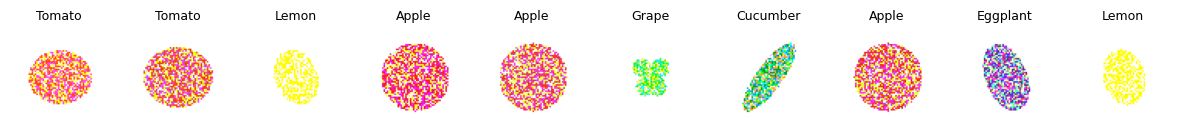

In [4]:
def create_canvas(size=64):
    return np.ones((size, size, 3), dtype=np.uint8) * 255

def add_noise(img):
    noise = np.random.normal(0, 8, img.shape).astype(np.uint8)
    return cv2.add(img, noise)

def generate_complex_fruit(name, img_size=64):
    img = create_canvas(img_size)
    cx, cy = img_size // 2, img_size // 2
    
    # --- 红色系 ---
    if name == 'Apple': # 圆，红
        r = random.randint(18, 22)
        color = (random.randint(20, 50), random.randint(20, 50), random.randint(200, 255))
        cv2.circle(img, (cx, cy), r, color, -1)
    elif name == 'Tomato': # 稍扁的圆，红偏橘
        axes = (random.randint(18, 22), random.randint(15, 19))
        color = (random.randint(10, 40), random.randint(40, 80), random.randint(220, 255))
        cv2.ellipse(img, (cx, cy), axes, 0, 0, 360, color, -1)
    elif name == 'Cherry': # 小圆，深红
        r = random.randint(8, 12)
        color = (random.randint(0, 30), random.randint(0, 20), random.randint(180, 230))
        cv2.circle(img, (cx, cy), r, color, -1)
        # 画个梗
        cv2.line(img, (cx, cy-r), (cx+5, cy-r-10), (0, 100, 0), 1)
        
    # --- 黄色系 ---
    elif name == 'Banana': # 长条，弯曲，黄
        axes = (random.randint(22, 28), random.randint(8, 10))
        angle = random.randint(30, 150)
        color = (0, random.randint(220, 255), random.randint(220, 255))
        cv2.ellipse(img, (cx, cy), axes, angle, 0, 360, color, -1)
    elif name == 'Lemon': # 椭圆，黄
        axes = (random.randint(18, 22), random.randint(12, 15))
        angle = random.randint(0, 180)
        color = (0, random.randint(240, 255), random.randint(240, 255))
        cv2.ellipse(img, (cx, cy), axes, angle, 0, 360, color, -1)
    elif name == 'Corn': # 长矩形，淡黄
        w, h = random.randint(10, 14), random.randint(30, 40)
        color = (50, 230, 240)
        cv2.rectangle(img, (cx-w//2, cy-h//2), (cx+w//2, cy+h//2), color, -1)
        
    # --- 绿色系 ---
    elif name == 'Cucumber': # 细长，深绿
        axes = (random.randint(25, 30), random.randint(6, 8))
        angle = random.randint(45, 135)
        color = (random.randint(0, 50), random.randint(150, 200), random.randint(0, 50))
        cv2.ellipse(img, (cx, cy), axes, angle, 0, 360, color, -1)
    elif name == 'Pear': # 上小下大(用水滴模拟)，浅绿
        color = (random.randint(0, 50), random.randint(200, 240), random.randint(150, 180))
        cv2.circle(img, (cx, cy+5), 15, color, -1)
        cv2.circle(img, (cx, cy-8), 10, color, -1)
    elif name == 'Grape': # 一串圆，青绿
        color = (random.randint(0, 30), random.randint(200, 255), random.randint(0, 50))
        for dx, dy in [(-6,-6), (6,-6), (0,0), (-4,6), (4,6)]:
            cv2.circle(img, (cx+dx, cy+dy), 6, color, -1)

    # --- 紫色系 ---
    elif name == 'Eggplant': # 长椭圆，紫
        axes = (random.randint(20, 26), random.randint(10, 13))
        angle = random.randint(60, 120)
        color = (random.randint(100, 150), random.randint(0, 50), random.randint(80, 120))
        cv2.ellipse(img, (cx, cy), axes, angle, 0, 360, color, -1)

    return add_noise(img)

# 生成数据 (每类 50 张，共 500 张)
categories = ['Apple', 'Tomato', 'Cherry', 'Banana', 'Lemon', 'Corn', 'Cucumber', 'Pear', 'Grape', 'Eggplant']
images = []
labels_true = []

print("⏳ 正在生成 500 张合成图片...")
for cat in categories:
    for _ in range(50):
        images.append(generate_complex_fruit(cat))
        labels_true.append(cat)

print("✅ 生成完毕！")

# 随机展示一批
indices = np.random.choice(len(images), 10, replace=False)
plt.figure(figsize=(15, 3))
for i, idx in enumerate(indices):
    plt.subplot(1, 10, i+1)
    plt.imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
    plt.title(labels_true[idx], fontsize=9)
    plt.axis('off')
plt.show()

## 3. 多维特征提取 (Feature Engineering)

对于 10 类物体，仅靠颜色是不够的。我们需要设计更丰富的特征向量：

1.  **颜色特征 (3维)**: R_mean, G_mean, B_mean (反映物体的颜色)
2.  **形状特征 (1维)**: **长宽比 (Aspect Ratio)**。 
    * $Ratio = Width / Height$
    * 圆形物体 (苹果) Ratio $\approx 1.0$
    * 长条物体 (香蕉、黄瓜) Ratio 会很大或很小 (取决于角度)
    * *注：为了具有旋转不变性，我们通常取 $max(w,h) / min(w,h)$ 作为长宽比特征。*

**最终特征向量**: `[R, G, B, Aspect_Ratio]` (4维)

In [5]:
def extract_advanced_features(image):
    # 1. 颜色特征
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # 简单的阈值分割
    _, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
    
    # 计算颜色均值
    mean_color = cv2.mean(img_rgb, mask=mask)[:3]
    
    # 2. 形状特征 (长宽比)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        c = max(contours, key=cv2.contourArea) # 找最大的轮廓
        x, y, w, h = cv2.boundingRect(c)
        # 计算长宽比 (长边/短边)，这样对旋转不敏感
        aspect_ratio = max(w, h) / (min(w, h) + 1e-5)
    else:
        aspect_ratio = 1.0
        
    return np.array([mean_color[0], mean_color[1], mean_color[2], aspect_ratio])

# 提取特征
data_matrix = []
for img in images:
    data_matrix.append(extract_advanced_features(img))

data_matrix = np.array(data_matrix)
print(f"原始特征矩阵形状: {data_matrix.shape}")

# 查看一下数据的范围
df_raw = pd.DataFrame(data_matrix, columns=['R', 'G', 'B', 'Aspect'])
print("\n数据统计描述 (注意看 Mean 和 Std 的巨大差异):")
print(df_raw.describe().loc[['mean', 'std', 'min', 'max']])

原始特征矩阵形状: (500, 4)

数据统计描述 (注意看 Mean 和 Std 的巨大差异):
               R           G           B    Aspect
mean  204.821189  187.372833   95.074668  1.540200
std    54.278870   64.361027   48.537719  0.677833
min    83.866667   77.721154    4.820976  0.999999
max   255.000000  255.000000  201.975945  4.384612


## 4. 数据标准化 (Standardization)

### ⚠️ 关键步骤
看上面的统计表，颜色值均值在 100-200 左右，而 Aspect Ratio 只有 1.5-3.0 左右。
K-Means 是基于**欧氏距离**的。如果不处理，颜色的差异（比如 100 和 110 差 10）会完全掩盖形状的差异（1.5 和 2.5 差 1）。
**形状特征将完全失效！**

我们必须使用 `StandardScaler` 将所有特征缩放到同一量纲（均值为 0，方差为 1）。

In [6]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_matrix)

print("标准化后的数据前 5 行:")
print(data_scaled[:5].round(2))

标准化后的数据前 5 行:
[[ 0.58 -1.22  0.04 -0.76]
 [ 0.89 -1.41  0.13 -0.76]
 [ 0.76 -1.24  0.41 -0.8 ]
 [ 0.4  -1.11  0.46 -0.8 ]
 [ 0.54 -1.39  0.03 -0.8 ]]


## 5. 确定最佳 K 值 (Elbow Method)

面对 10 类数据，K-Means 能准确找到 10 个中心吗？
我们绘制 K=1 到 K=15 的惯性曲线。

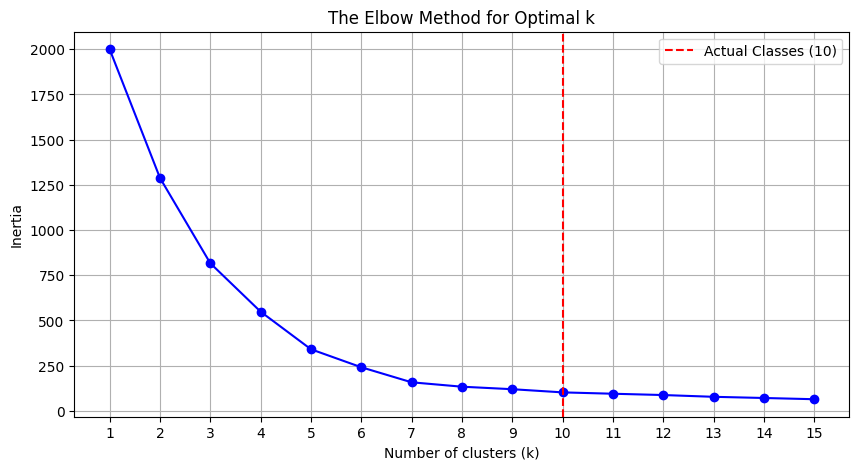

In [7]:
inertias = []
k_range = range(1, 16)

for k in k_range:
    # n_init='auto' 是新版 sklearn 推荐
    km = KMeans(n_clusters=k, random_state=42, n_init=10) 
    km.fit(data_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.title('The Elbow Method for Optimal k')
plt.grid(True)
plt.axvline(x=10, color='r', linestyle='--', label='Actual Classes (10)')
plt.legend()
plt.show()

## 6.1 聚类与结果分析

我们设定 K=10 进行聚类，并分析结果。
为了直观地看“聚类效果”，我们统计每个簇中包含的主要水果类别。

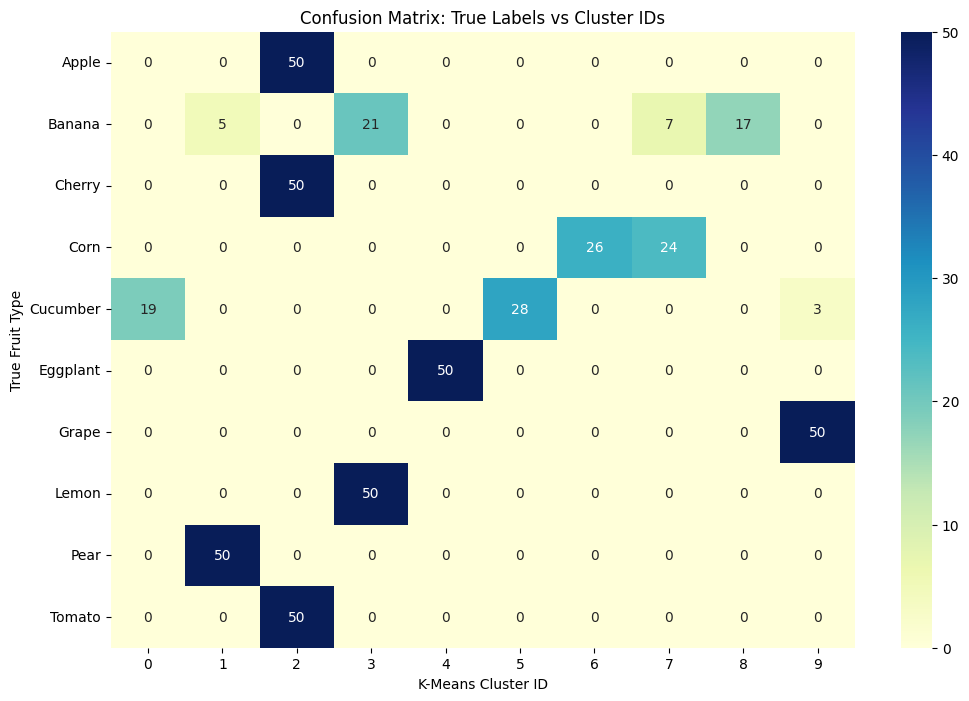

In [8]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data_scaled)

# 构建结果 DataFrame
df_res = pd.DataFrame({'True_Label': labels_true, 'Cluster': clusters})

# 混淆矩阵式的可视化
plt.figure(figsize=(12, 8))
ct = pd.crosstab(df_res['True_Label'], df_res['Cluster'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix: True Labels vs Cluster IDs")
plt.ylabel("True Fruit Type")
plt.xlabel("K-Means Cluster ID")
plt.show()

###  结果解读 (Result Interpretation)
看上面的热力图 (Heatmap)：
1.  **理想情况**：每一行应该只有一个深色方块（说明该水果全部分到了某一个簇）。
2.  **常见错误**：
    * **Apple vs Tomato**: 如果它们混在了一起，说明“颜色+长宽比”这两个特征还不足以区分它们（因为它们都是圆的、红的）。
    * **Banana vs Cucumber**: 应该能分得很好，因为颜色差异大（黄 vs 绿），且长宽比都很大，不会和 Apple 混淆。
    * **Lemon vs Banana**: 可能会混淆，因为颜色接近，如果 Lemon 画得比较扁长，就容易被误判。

## 6.2: PCA 降维分布图

我们的数据有 4 个维度 (R, G, B, 长宽比)，人类大脑无法想象 4D 空间。
使用 **PCA (主成分分析)** 技术，我们可以将 4D 数据“压扁”到 2D 平面上，同时尽可能保留原始信息。

**观察重点**：
1.  **不同颜色的点**代表 K-Means 聚出来的不同簇。
2.  **点的形状/文字**代表真实的水果标签。
3.  如果两个不同种类的水果（如 Apple 和 Tomato）在图上重叠了，说明模型在现有特征下无法区分它们。

C:\Users\86177\AppData\Local\Temp\ipykernel_23700\4034942235.py:34: UserWarning: The palette list has more values (15) than needed (10), which may not be intended.
  sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],


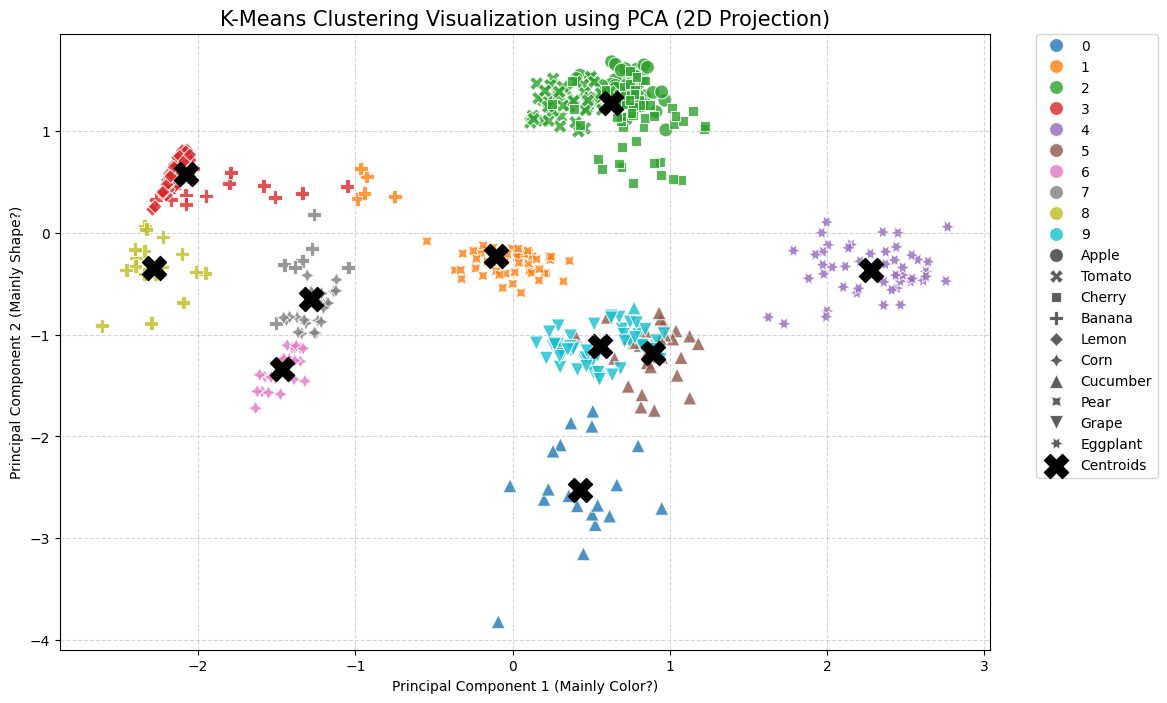

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

if 'kmeans' in locals() and 'data_scaled' in locals():
    cluster_labels = kmeans.fit_predict(data_scaled)
else:
    print("错误：请先运行前面的 Cell 以生成 'kmeans' 模型和 'data_scaled' 数据！")

# 1. 使用 PCA 将 4D 特征降维到 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_scaled)

# 2. 绘图
plt.figure(figsize=(12, 8))

# 定义颜色映射
palette = sns.color_palette("tab10", k) # 确保 k 变量也存在，通常是 10

# 绘制散点图
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], 
                hue=cluster_labels, # 现在这个变量已经定义了
                palette=palette, 
                style=labels_true,  # 形状由真实标签决定 (用于对比)
                s=100, alpha=0.8)

# 绘制聚类中心 (也需要 PCA 变换)
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
            s=300, c='black', marker='X', label='Centroids')

plt.title("K-Means Clustering Visualization using PCA (2D Projection)", fontsize=15)
plt.xlabel("Principal Component 1 (Mainly Color?)")
plt.ylabel("Principal Component 2 (Mainly Shape?)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6.3: 轮廓系数分析

**轮廓系数 (Silhouette Coefficient)** 是衡量聚类质量的核心指标，范围 [-1, 1]。
* **接近 1**: 聚类效果极好（自己人离得近，外人离得远）。
* **接近 0**: 处于边界上，模棱两可。
* **负数**: 分错类了。

下图的**每一条横线代表一个样本**。如果某个簇的“刀形”很宽且超过红线（平均分），说明这个簇聚得很棒。

For n_clusters = 15, The average silhouette_score is : 0.6384


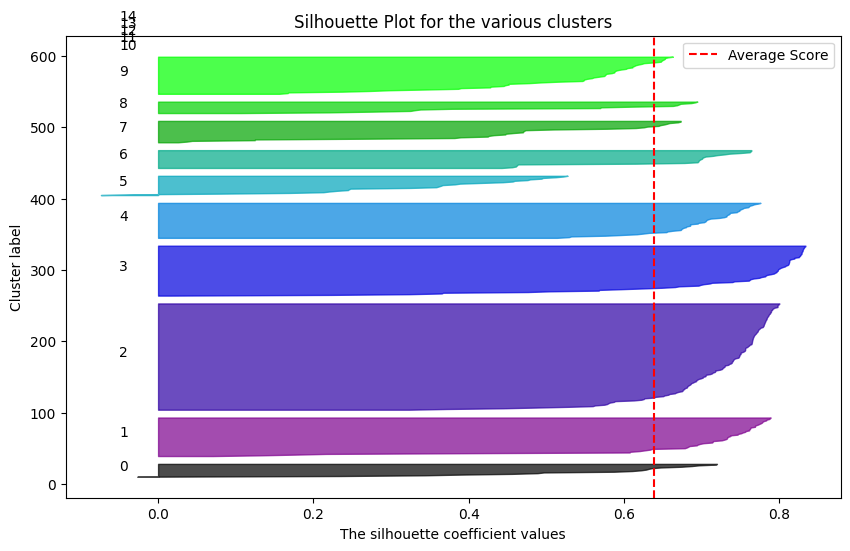

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

if 'k' not in locals():
    k = 10

# 确保 cluster_labels 存在
if 'cluster_labels' not in locals():
    if 'kmeans' in locals() and 'data_scaled' in locals():
        cluster_labels = kmeans.fit_predict(data_scaled)
    else:
        print("❌ 错误：缺少 kmeans 模型或 data_scaled 数据，请先运行前面的训练代码！")


# 计算平均轮廓系数
silhouette_avg = silhouette_score(data_scaled, cluster_labels)
print(f"For n_clusters = {k}, The average silhouette_score is : {silhouette_avg:.4f}")

# 计算每个样本的轮廓系数
sample_silhouette_values = silhouette_samples(data_scaled, cluster_labels)

plt.figure(figsize=(10, 6))
y_lower = 10

for i in range(k):
    # 提取第 i 个簇的轮廓系数
    ith_cluster_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_values.sort()

    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # 使用 matplotlib 的颜色映射
    color = cm.nipy_spectral(float(i) / k)
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # 标注簇编号
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label="Average Score")
plt.title("Silhouette Plot for the various clusters")
plt.xlabel("The silhouette coefficient values")
plt.ylabel("Cluster label")
plt.legend()
plt.show()

## 7. 学生拓展与思考 (Design Thinking)

###  深度思考题

1.  **关于标准化 (Normalization)**：
    * 尝试把第 4 步的 `StandardScaler` 代码注释掉，直接用原始数据跑 K-Means。观察热力图会有什么变化？
    * *预测*：是否颜色差异大的物体（如红 vs 绿）还能分开，但形状差异大的物体（苹果 vs 香蕉）分不开了？

2.  **特征设计的缺陷**：
    * 从结果看，Apple 和 Tomato 很难区分。请设计一个能区分它们的**新特征**。
    * *提示*：番茄通常比苹果更“光滑”或更“扁”，或者番茄的绿色蒂头形状不同。但在 64x64 像素下，也许**纹理 (Texture)** 是个突破口？

3.  **K 值的选择**：
    * 看肘部法则的图，曲线在 K=10 时是否真的有明显的“肘部”？
    * 如果没有（曲线很平滑），说明了什么？（提示：说明这 10 类数据在特征空间中可能有重叠，并不是完美的 10 个孤岛）。

###  解答思路

<details>
<summary><strong>点击查看参考答案</strong></summary>

#### 1. 不标准化的后果
如果不标准化，颜色的权重是形状的 100 倍。模型会变成“只看颜色”的模型。于是 Apple(圆红) 和 Banana(长黄) 能分开，但 Banana(长黄) 和 Lemon(圆黄) 就会混在一起，因为模型看不见形状的区别。

#### 2. 区分 Apple 和 Tomato
这是一个难题。在简单特征下几乎无法区分。可能的改进：
* **色调直方图 (Hue Histogram)**: 番茄的红可能偏橘，苹果的红可能偏深。
* **边缘复杂度**: 樱桃有梗，番茄有蒂，苹果较圆滑。

#### 3. 肘部不明显
真实数据往往如此。当类别之间有过渡（例如圆柠檬和长柠檬，长番茄和圆番茄）时，聚类边界是模糊的。这时候 K 的选择更多依赖业务需求（比如我们需要分得细一点还是粗一点），而不仅仅是数学指标。

</details>